In [1]:
import numpy as np  # import numerical python
import matplotlib.pyplot as plt  # import plotting functions
import seaborn as sns  # import nicer plotting functions
import polars as pl  # import polars to import data
import tifffile as tiff
from tifffile import imwrite, imread
from copy import deepcopy
import os

import sys

sys.path.append("..")

# Modern import pattern - unified simulation method with strategy pattern
from src import Multicolour_Simulation_Functions
from src.Multicolour_Simulation_Functions import FittingStrategy, SimulationConfig

# Additional required components not integrated into main simulation class
from src import PlottingFunctions
from src import SpectralFunctions
from src import MaskFunctions
from src import HelperFunctions

# Create main simulation instance (contains IO, PSF, sCMOS, ImageAnalysis dependencies)
MSF = Multicolour_Simulation_Functions.MultiC_Sim_Funcs()

# Access integrated components through MSF
IO = MSF.io
I_AF = MSF.image_analysis
sCMOS = MSF.scmos
PSF = MSF.psf

# Create instances of non-integrated components
plotter = PlottingFunctions.Plotter()
S_F = SpectralFunctions.Spectral_Funcs()
M_F = MaskFunctions.Mask_Functions()
H_F = HelperFunctions.Helper_Functions()

INFO:Constants:Logging to file: /home/jbeckwith/Documents/pCloud/Chemistry/Lee/Code/Python/pyBayerSMLM/logs/Constants_20250909_102715.log


In [2]:
data_folder = "../Camera_Calibrations/Ximea_Camera/"
gain = IO.read_tiff(os.path.join(data_folder, "gain.tif"))
offset = IO.read_tiff(os.path.join(data_folder, "offset.tif"))
variance = IO.read_tiff(os.path.join(data_folder, "variance.tif"))
readnoise = IO.read_tiff(os.path.join(data_folder, "readnoise.tif"))
rqe = IO.read_tiff(os.path.join(data_folder, "rqe.tif"))
R, G, B, wavelength = S_F.getpixelefficiency()

In [3]:
notch_filter = "semrock-nf03-405-488-561-635e"
dichroic_mirror = "semrock-di03-r405-488-561-635-t1-25x36"
shortpass_filter = "semrock-bsp01-785r"
filters = [notch_filter, dichroic_mirror, shortpass_filter]

In [4]:
n_photon_space = np.logspace(np.log10(500), np.log10(750000), 100)
n_bootstrap = 20000
background_photons = 40
pixel_sizes = np.array([5])
NA = 1.49

In [5]:
import types

smoothing_function = types.SimpleNamespace()
smoothing_function.args = {"sigma": 1.5}
smoothing_function.extent = 1.5
smoothing_function.smoothing_function = sCMOS.gaussian_filter_stack
smoothing_function.data_arg = "image"

In [6]:
dyes = ["ATTO 565"]

In [7]:
save_folder = r"/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Data/Simulation/20250902_TestDemosaicking_vsPixelSize"
if not os.path.isdir(save_folder):
    os.makedirs(save_folder)

In [ ]:
for dye in dyes:
    print(
        "Analysing dye {}".format(dye),
        end="\r",
        flush=True,
    )
    # Modern approach: Use unified test_simulation_method with explicit strategy
    # Create simulation configuration using modern SimulationConfig approach
    for pixel_size in pixel_sizes:
        print(
            "Analysing dye {} at pixel size {}".format(dye, pixel_size),
            end="\r",
            flush=True,
        )
        # Create simulation configuration using modern SimulationConfig approach
        image_physical_dimension = 1000  # in nm
        image_size = int(image_physical_dimension / pixel_size)
        masks = M_F.get_masks(size_x=image_size, size_y=image_size)
        R, G, B, wavelength = S_F.getpixelefficiency()
        wavelength = wavelength
        pixel_QYs = np.vstack([B, G, R])
        camera_parameters = {}
        camera_parameters["gain"] = np.full((image_size, image_size), np.median(gain))
        camera_parameters["variance"] = np.full(
            (image_size, image_size), np.median(variance)
        )
        camera_parameters["readnoise"] = np.full(
            (image_size, image_size), np.median(readnoise)
        )
        camera_parameters["offset"] = np.full(
            (image_size, image_size), np.median(offset)
        )
        camera_parameters["rqe"] = np.full((image_size, image_size), np.median(rqe))
        camera_parameters["pixel_QYs"] = pixel_QYs
        camera_parameters["pixel_order"] = ["B", "G", "R"]
        camera_parameters["pixel_order_indices"] = [0, 1, 2]
        camera_parameters["masks"] = masks
        simulation_config = SimulationConfig(
            n_bootstrap=n_bootstrap,
            background_photons=background_photons,
            NA=NA,
            pixel_size=pixel_size,
            cpu_fraction=0.9,
            save_raw_results=False,
            subtractx0y0=False,
            saverawimages=False,
        )

        MSF.test_simulation_method(
            dye=dye,
            filters=filters,
            wavelength=wavelength,
            camera_parameters=camera_parameters,
            save_folder=save_folder,
            n_photon_space=n_photon_space,
            smoothing_function=smoothing_function,
            strategy=FittingStrategy.DEMOSAIC,  # Explicit strategy specification
            starting_flag="demosaic_pixelsize_" + str(int(pixel_size)) + "_",
            config=simulation_config,  # All additional parameters via config object
        )
        MSF.test_simulation_method(
            dye=dye,
            filters=filters,
            wavelength=wavelength,
            camera_parameters=camera_parameters,
            save_folder=save_folder,
            n_photon_space=n_photon_space,
            smoothing_function=smoothing_function,
            strategy=FittingStrategy.STANDARD,  # Explicit strategy specification
            starting_flag="standard_pixelsize_" + str(int(pixel_size)) + "_",
            config=simulation_config,  # All additional parameters via config object
        )

In [8]:
folder = "/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Data/Simulation/20250902_TestDemosaicking_vsPixelSize/"
files = H_F.file_search(folder, "RMSE_mean", "ATTO 565")

In [9]:
demosaic_files = np.sort([x for x in files if "demosaic" in x])
standard_files = np.sort([x for x in files if "standard" in x])

In [28]:
pixel_size = np.array([10, 20, 30, 40, 50, 60, 70, 80, 90, 100])

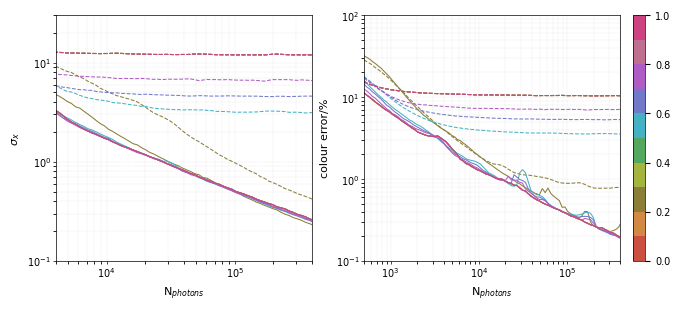

In [30]:
fig, axs = plotter.two_column_plot(ncolumns=2, widthratio=[1, 1])

cs = [
    "#cb5041",
    "#d28943",
    "#8a7e39",
    "#a3b53d",
    "#55a75f",
    "#45b2c4",
    "#7179cb",
    "#b05cc6",
    "#c16f90",
    "#cd4382",
]

for c, pixel in enumerate(pixel_size):
    data_demosaic = pl.read_csv(
        np.array([x for x in demosaic_files if str(pixel) in x])[0]
    )
    data_standard = pl.read_csv(
        np.array([x for x in standard_files if str(pixel) in x])[0]
    )

    axs[0] = plotter.line_plot(
        axs[0],
        data_standard["n_photons"].to_numpy(),
        data_standard["xc"].to_numpy(),
        label="full analysis",
        xaxislabel=r"N$_{photons}$",
        color=cs[c],
        yaxislabel=r"$\sigma_x$",
    )

    axs[0] = plotter.line_plot(
        axs[0],
        data_demosaic["n_photons"].to_numpy(),
        data_demosaic["xc"].to_numpy(),
        label="demosaic analysis",
        xaxislabel=r"N$_{photons}$",
        color=cs[c],
        ls="--",
        yaxislabel=r"$\sigma_x$",
    )

    axs[0].set_yscale("log")
    axs[0].set_xscale("log")
    axs[0].set_ylim([0.1, 30])
    axs[0].set_xlim([4000, 400000])

    axs[1] = plotter.line_plot(
        axs[1],
        data_standard["n_photons"].to_numpy(),
        100 * data_standard["colour_distance"].to_numpy(),
        label="full analysis",
        xaxislabel=r"N$_{photons}$",
        color=cs[c],
        yaxislabel=r"$\sigma_x$",
    )
    axs[1] = plotter.line_plot(
        axs[1],
        data_demosaic["n_photons"].to_numpy(),
        100 * data_demosaic["colour_distance"].to_numpy(),
        label="demosaic analysis",
        xaxislabel=r"N$_{photons}$",
        color=cs[c],
        ls="--",
        yaxislabel=r"colour error/%",
    )

    axs[1].set_ylim([0.1, 100])
    axs[1].set_xlim([500, 400000])

    axs[1].set_yscale("log")
    axs[1].set_xscale("log")

from matplotlib.colors import LinearSegmentedColormap

my_cmap = LinearSegmentedColormap.from_list("my_cmap", cs, N=10)
sm = plt.cm.ScalarMappable(cmap=my_cmap)
plt.colorbar(sm, ax=axs[1])

plt.savefig(
    "/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Talks+Posters/Subgroup/20250911/fig/multicolour/demosaicking_analysis/Steve_vs_Joe.svg",
    dpi=600,
    format="svg",
)
plt.show()